# The Mental Model: 3 Questions Per Feature
Before any code, burn this into your brain. For every feature, you ask three questions: Does it correlate with the target (relevance)? Does it duplicate another feature already in the dataset (redundancy)? Does it give new information beyond what other features already provide (unique contribution)? The tools in this session measure exactly those three things.

# Chapter 1: Correlation with Target — The First Pass

### For a Numerical Target (Regression)

In [1]:
import pandas as pd,numpy as np,matplotlib.pyplot as plt,seaborn as sns
from scipy import stats

In [3]:
# We'll use Titanic throughout, with Survived as the binary target
# For regression examples we'll simulate a continuous target (house prices)

df = pd.read_csv("../data/titanic.csv")
# ── Step 1: Point-biserial / Pearson correlation with binary target ──
target = 'Survived'
num_features = ['Age' , 'Fare' , 'SibSp' , 'Parch' , 'Pclass']
print("Correlation with Survived:")
print("=" * 45)
corr_results = []
for col in num_features:
    data = df[[col, target]].dropna()
    r, p = stats.pointbiserialr(data[target], data[col])
    corr_results.append({'feature': col, 'r': r, 'p_value': p,
                          'abs_r': abs(r), 'significant': p < 0.05})
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"  {col:<10} r={r:+.4f}  p={p:.4f}  {sig}")

Correlation with Survived:
  Age        r=-0.0772  p=0.0391  *
  Fare       r=+0.2573  p=0.0000  ***
  SibSp      r=-0.0353  p=0.2922  
  Parch      r=+0.0816  p=0.0148  *
  Pclass     r=-0.3385  p=0.0000  ***


### For a Categorical Target (Classification) — Cramer's V

In [4]:
# For categorical features vs binary target → chi-square + Cramér's V
cat_features = ['Sex', 'Embarked', 'Pclass']

print("\nAssociation with Survived (categorical features):")
print("=" * 50)
for col in cat_features:
    ct = pd.crosstab(df[col], df[target])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    print(f"  {col:<12} Cramér's V={v:.4f}  p={p:.2e}")



Association with Survived (categorical features):
  Sex          Cramér's V=0.5409  p=1.20e-58
  Embarked     Cramér's V=0.1726  p=1.77e-06
  Pclass       Cramér's V=0.3398  p=4.55e-23


# Chapter 2: Feature Importance — Beyond Simple Correlation
Correlation only captures linear relationships. A feature could be useless in a linear sense but be a powerful non-linear predictor. That's why we use information-theoretic and model-based importance measures.
Mutual Information — The Information Theory Approach
Mutual information (MI) measures how much knowing a feature reduces uncertainty about the target. Correlation = 0 does NOT mean MI = 0. MI can detect any relationship — linear, curved, step-function, anything.

In [5]:
from sklearn.feature_selection import (
    mutual_info_classif,
    mutual_info_regression,
    f_classif,
    f_regression
)
from sklearn.preprocessing import LabelEncoder

# Prepare the data 
df_model = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp',
               'Parch', 'Fare', 'Embarked']].dropna().copy()

# Encode categorical columns
le = LabelEncoder()
df_model['Sex_enc']      = le.fit_transform(df_model['Sex'])
df_model['Embarked_enc'] = le.fit_transform(df_model['Embarked'])

features = ['Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_enc']
X = df_model[features]
y = df_model['Survived']

# Mutual Information (classification) 
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'feature':    features,
    'mi_score':   mi_scores
}).sort_values('mi_score', ascending=False)

print("Mutual Information Scores:")
print(mi_df.round(4).to_string(index=False))

Mutual Information Scores:
     feature  mi_score
     Sex_enc    0.1607
        Fare    0.1297
      Pclass    0.0665
       Parch    0.0299
       SibSp    0.0281
Embarked_enc    0.0235
         Age    0.0000


Interpreting MI scores: MI = 0 means complete independence. MI > 0 means the feature and target share information. There is no fixed scale like correlation's −1 to +1 — you interpret MI comparatively. In this example, Sex_enc has roughly 3.5× more information about survival than Fare.

### ANOVA F-Score — Linear Discriminative Power
The F-score tests whether the means of a feature differ significantly across target classes. It is fast, interpretable, and the sklearn standard for filter-based feature selection.

In [6]:
# ANOVA F-score (classification) 
f_scores, p_values = f_classif(X, y)

f_df = pd.DataFrame({
    'feature':  features,
    'f_score':  f_scores,
    'p_value':  p_values
}).sort_values('f_score', ascending=False)

print("\nANOVA F-Scores:")
print(f_df.round(4).to_string(index=False))



ANOVA F-Scores:
     feature  f_score  p_value
     Sex_enc 287.3494   0.0000
      Pclass 103.3479   0.0000
        Fare  54.1055   0.0000
Embarked_enc  24.3180   0.0000
       Parch   6.5026   0.0110
         Age   4.8591   0.0278
       SibSp   0.1711   0.6792


# Chapter 3: Multicollinearity — When Features Explain Each Other
Multicollinearity is when two or more features are highly correlated with each other, not just with the target. This is a serious problem because it makes it impossible for the model to tell which feature is actually causing the prediction. It inflates coefficient uncertainty and can make coefficients flip sign.
Variance Inflation Factor (VIF) — The Standard Diagnostic
VIF for feature X answers: "how much of feature X can be explained by all the other features combined?" VIF = 1 means no multicollinearity. VIF = 5 is concerning. VIF > 10 is a serious problem that must be addressed.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Compute VIF for all numerical features 
vif_df = df_model[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].dropna()

# VIF requires adding a constant (intercept column)
X_vif = add_constant(vif_df)

vif_results = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
})

# Remove the constant row
vif_results = vif_results[vif_results['feature'] != 'const']
vif_results = vif_results.sort_values('VIF', ascending=False)

print("Variance Inflation Factors:")
for _, row in vif_results.iterrows():
    flag = '  PROBLEMATIC' if row['VIF'] > 10 else '  concerning' if row['VIF'] > 5 else ''
    print(f"  {row['feature']:<12} VIF = {row['VIF']:.2f}{flag}")

Variance Inflation Factors:
  Pclass       VIF = 1.70
  Fare         VIF = 1.58
  Age          VIF = 1.29
  SibSp        VIF = 1.27
  Parch        VIF = 1.23


# Chapter 4: Interaction Effects
An interaction effect means the effect of feature A on the target depends on the value of feature B. Individually, A and B might look weak; together they are strong. Missing interactions is one of the most common mistakes in EDA.

In [9]:
# Detecting interaction effects visually 
# Does Sex moderate the effect of Pclass on Survival?

pivot = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
print("Survival rate by Pclass × Sex:")
print(pivot.round(3))

Survival rate by Pclass × Sex:
Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


In [10]:
# Insight: For females, going from 1st to 3rd class drops survival
# from 97% to 50%. For males, the range is 37% to 13%.
# The SEX × PCLASS interaction is massive.

#  Statistical test for interaction 
import statsmodels.formula.api as smf

# Logistic regression with interaction term
model_no_interaction = smf.logit(
    'Survived ~ Pclass + C(Sex)',
    data=df_model
).fit(disp=False)

model_with_interaction = smf.logit(
    'Survived ~ Pclass * C(Sex)',   # * creates main effects + interaction
    data=df_model
).fit(disp=False)

# Likelihood ratio test
lr_stat = 2 * (model_with_interaction.llf - model_no_interaction.llf)
lr_p    = stats.chi2.sf(lr_stat, df=1)

print(f"\nLikelihood ratio test (interaction term significance):")
print(f"  LR statistic : {lr_stat:.4f}")
print(f"  p-value      : {lr_p:.4f}")
# p < 0.05 -> the interaction term significantly improves the model
# → Keep Sex × Pclass as a feature

# Create the interaction feature manually 
df_model['Sex_Pclass'] = df_model['Sex_enc'] * df_model['Pclass']
# This captures the combined effect in a single engineered feature


Likelihood ratio test (interaction term significance):
  LR statistic : 22.5907
  p-value      : 0.0000


### Visual Interaction: The Interaction Plot

C:\Users\sai charan\AppData\Local\Temp\ipykernel_25720\1665115266.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_heat = pivot_age_class.groupby(['AgeGroup','Pclass'])['Survived'].mean().unstack()


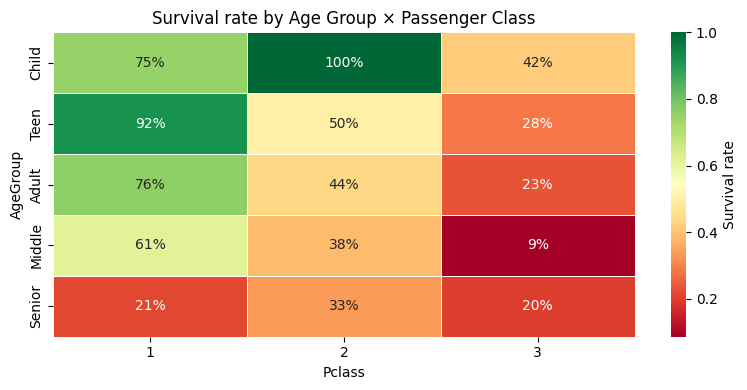

In [11]:
# Heatmap of survival rate by two categorical features
# This is the most powerful visual for spotting interactions

pivot_age_class = df.copy()
pivot_age_class['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                                      labels=['Child','Teen','Adult','Middle','Senior'])
pivot_heat = pivot_age_class.groupby(['AgeGroup','Pclass'])['Survived'].mean().unstack()

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_heat, annot=True, fmt='.0%', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Survival rate'})
plt.title('Survival rate by Age Group × Passenger Class')
plt.tight_layout()
plt.show()

# Chapter 5: The Feature Selection Decision — Keep or Drop?
This is the final synthesis. Combine every signal from the previous chapters into an actionable decision for each feature.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

#  Model-based importance as a final validator
# Random Forest importance accounts for interactions automatically

le = LabelEncoder()
df_rf = df_model.copy()
df_rf['Sex_enc'] = le.fit_transform(df_rf['Sex'])
df_rf['Embarked_enc'] = le.fit_transform(df_rf['Embarked'].fillna('S'))

feat_cols = ['Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_enc']
X_rf = df_rf[feat_cols]
y_rf = df_rf['Survived']

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_rf, y_rf)

rf_importance = pd.DataFrame({
    'feature': feat_cols,
    'rf_importance': rf.feature_importances_
}).sort_values('rf_importance', ascending=False)

print("Random Forest Feature Importances:")
print(rf_importance.round(4).to_string(index=False))

Random Forest Feature Importances:
     feature  rf_importance
         Age         0.2836
        Fare         0.2552
     Sex_enc         0.2501
      Pclass         0.0985
       SibSp         0.0461
       Parch         0.0392
Embarked_enc         0.0273


In [13]:
# After the audit, apply these rules:

# ALWAYS DROP:
# 1. VIF > 10 (severe multicollinearity) — keep only the most interpretable one
# 2. p-value > 0.05 AND MI near zero (no relationship at all)
# 3. Near-zero variance (>95% same value — useless for any model)

# ALWAYS KEEP:
# 1. High MI score (top 30% by MI)
# 2. Significant F-score (p < 0.01)
# 3. High RF importance (> 10% of max)
# 4. Confirmed by domain knowledge (e.g., age in medical datasets)

# REVIEW MANUALLY:
# 1. High MI but high VIF → may carry info, but collinear → consider PCA
# 2. Low MI but domain says it matters → investigate further, check encoding
# 3. Non-linear predictor (MI high, F low) → tree models will use it well

# Final feature set selection 
features_to_keep  = ['Sex_enc', 'Pclass', 'Fare', 'Age']
features_to_review = ['Embarked_enc', 'Parch']
features_to_drop  = ['SibSp']   # Low MI + non-significant F-score

print("FINAL FEATURE DECISIONS:")
print(f"  Keep   : {features_to_keep}")
print(f"  Review : {features_to_review}")
print(f"  Drop   : {features_to_drop}")

# Note: SibSp and Parch could be COMBINED into FamilySize
df_model['FamilySize'] = df_model['SibSp'] + df_model['Parch']
# A 0-person family (alone) had very different survival than a 2-4 person family

FINAL FEATURE DECISIONS:
  Keep   : ['Sex_enc', 'Pclass', 'Fare', 'Age']
  Review : ['Embarked_enc', 'Parch']
  Drop   : ['SibSp']


# Summary: The Feature Decision Cheat Sheet
The full methodology in plain English. First, measure relevance with correlation (for linear), MI (for any relationship), and F-score (for group mean differences). Features with near-zero MI and non-significant F-score across all three have no information to contribute — drop them without hesitation.
Second, measure redundancy with VIF. If two features have VIF > 10, they are almost perfectly collinear — keep the one that is more interpretable or more directly related to the target, drop the other. If you need both for interpretability, apply PCA to combine them.
Third, investigate interactions by building pivot tables of target mean grouped by two features simultaneously. If the pattern in one feature completely reverses across values of another, you have an interaction — encode it as A × B engineered feature.
Finally, use Random Forest importance as the ultimate validator, because it handles non-linearity, interactions, and feature correlations simultaneously. If the RF agrees with MI and correlation on what matters, you can be confident. If RF ranks a feature high that correlation ranked low, that feature has a non-linear effect that linear methods missed — keep it.